# Local Ancestry Visualization

Local ancestry can be viewed at two levels: chromosome paintings for individual genomes, and matrix-style cohort plots for many samples. This tutorial starts with full-chromosome paintings, then uses `plot_lai` for a dataset-level view.

## Build full-genome local ancestry

`build_synthetic_chromosome_painting_dataset()` creates local ancestry windows.

In [10]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from snputils.datasets import build_synthetic_chromosome_painting_dataset
from snputils.visualization import chromosome_painting
from snputils.visualization.lai import plot_lai

RESULTS_DIR = Path("results/tutorials/local_ancestry")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SEED = 20240520

painting_dataset = build_synthetic_chromosome_painting_dataset(
    n_samples=20,
    windows_per_chromosome=60,
    seed=SEED,
    build="hg38",
    ancestry_map={"0": "AFR", "1": "EUR", "2": "EAS"},
)

laiobj = painting_dataset["laiobj"]
build = painting_dataset["build"]
selected_samples = laiobj.samples[:3]

print(laiobj)
selected_samples

LocalAncestryObject(shape=(1320, 40), n_windows=1320, n_samples=20, n_haplotypes=40, n_ancestries=3, has_window_metadata=True, has_ancestry_map=True)


['sample0', 'sample1', 'sample2']

## Paint full chromosome sets

`chromosome_painting` can use the `LocalAncestryObject` directly. Here we paint three selected samples and display the resulting PNGs.

Chromosome painting 1/3 (sample0)


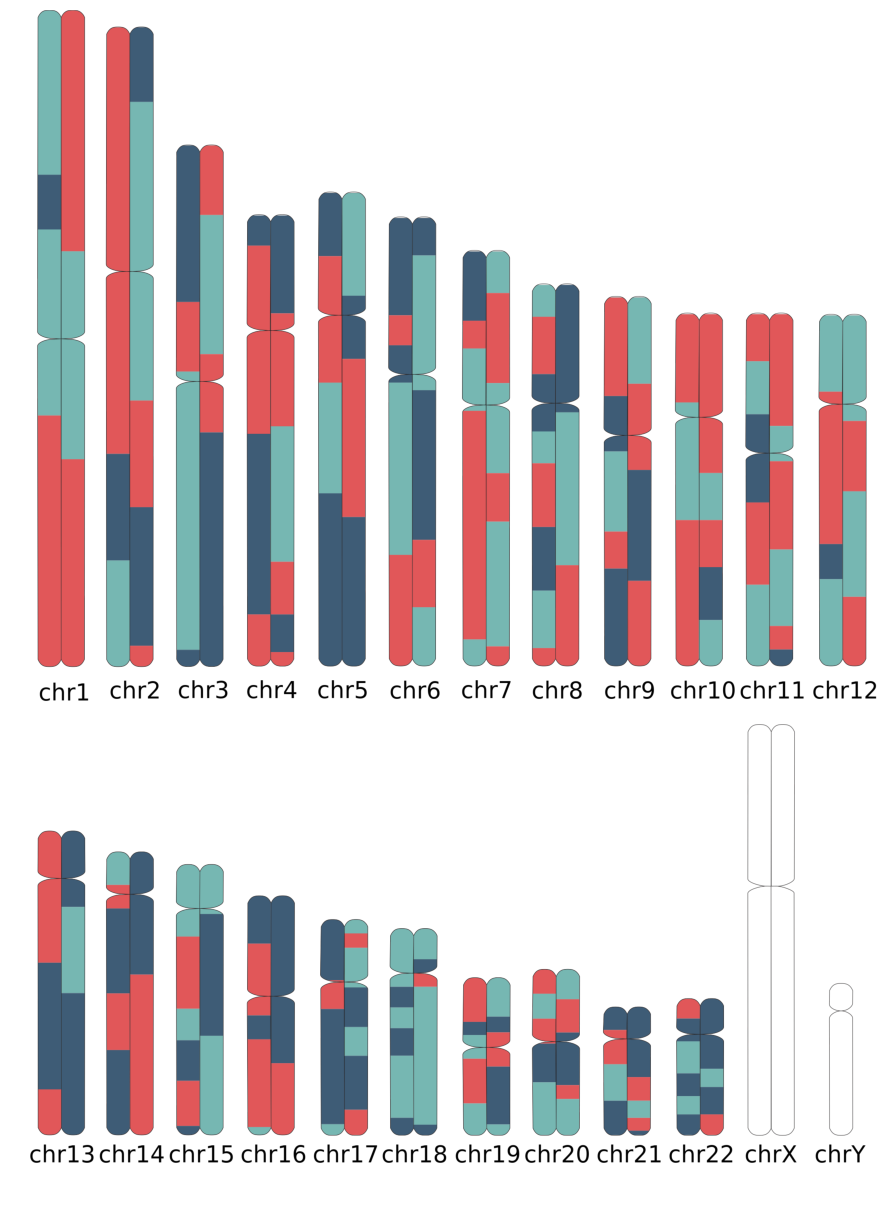

Chromosome painting 2/3 (sample1)


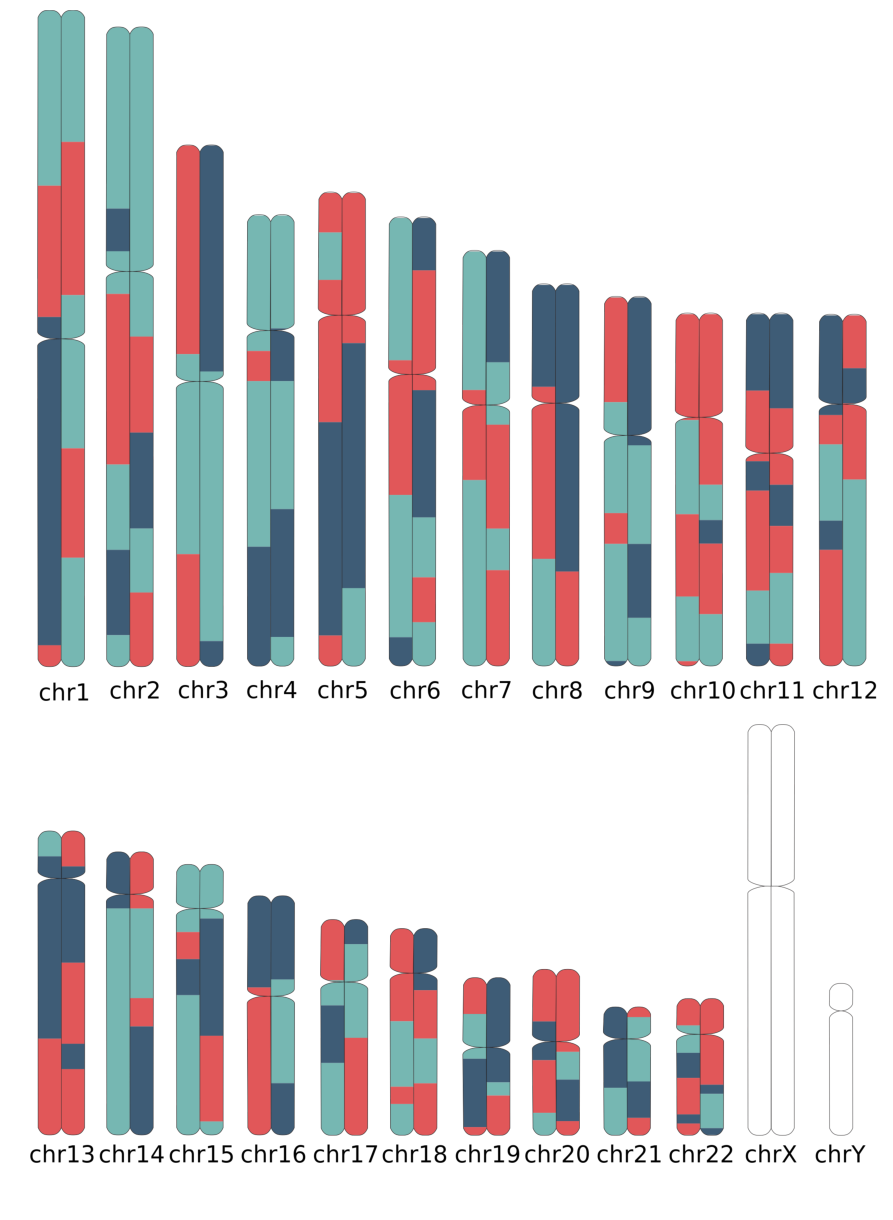

Chromosome painting 3/3 (sample2)


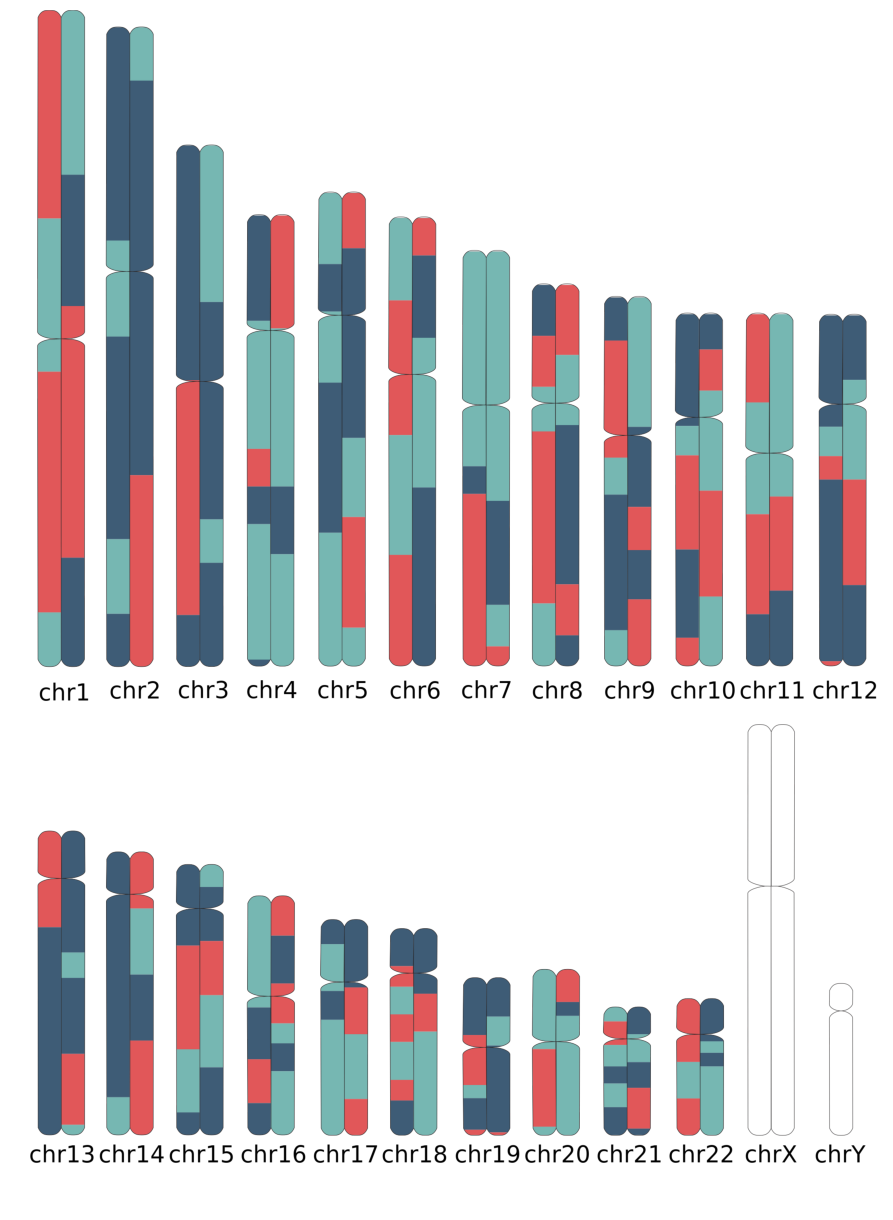

['results/tutorials/local_ancestry/paintings_from_laiobj/paintings/sample0.png',
 'results/tutorials/local_ancestry/paintings_from_laiobj/paintings/sample1.png',
 'results/tutorials/local_ancestry/paintings_from_laiobj/paintings/sample2.png']

In [11]:
from snputils.visualization.constants import get_palette_color

color_map = {0: get_palette_color(0), 1: get_palette_color(1), 2: get_palette_color(2)}

painting_outputs = chromosome_painting(
    source=laiobj,
    output_dir=RESULTS_DIR / "paintings_from_laiobj",
    sample_id=selected_samples,
    build=build,
    color_map=color_map,
    output_format="png",
    force=True,
    verbose=False,
    show=True
)

painting_outputs


## Dataset-level LAI plot

`plot_lai` shows many samples and windows in one matrix. For full-genome data, this is a compact overview rather than a chromosome-scale inspection tool; chromosome paintings above are better for reading one individual genome.

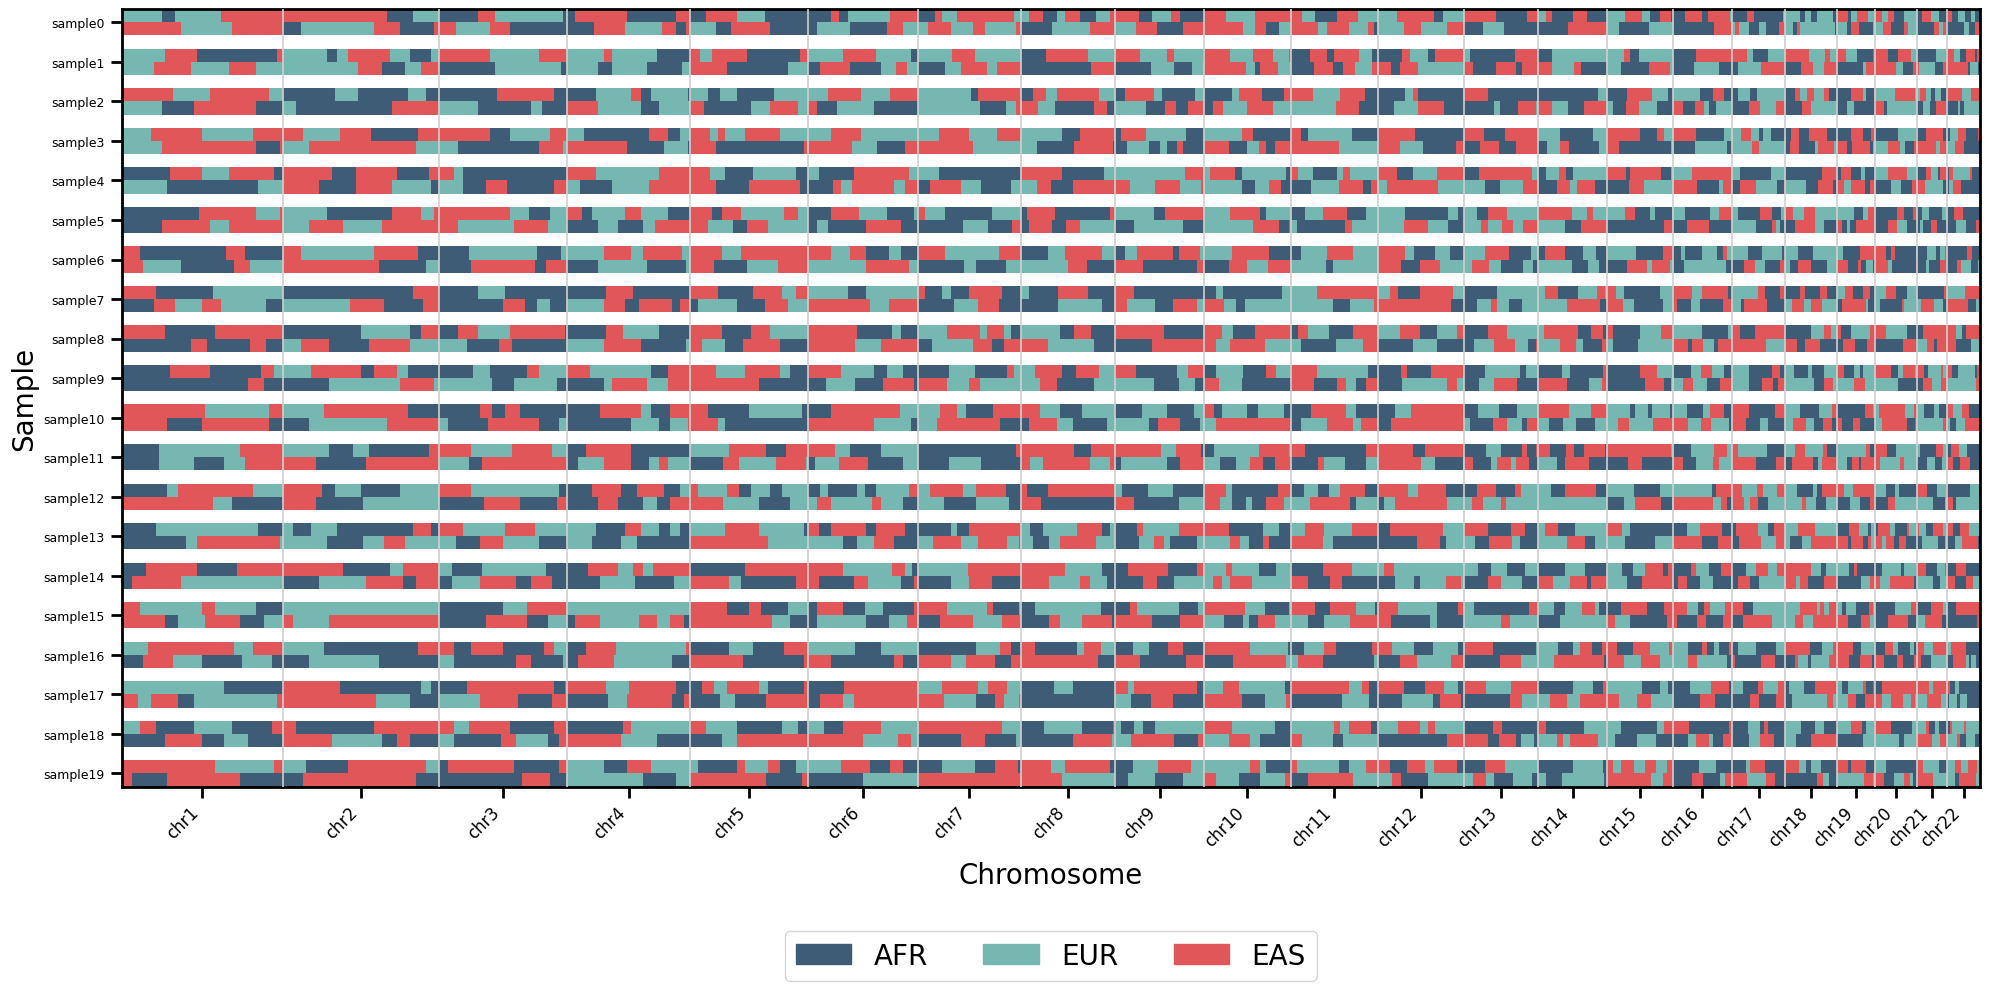

In [ ]:
colors = {"AFR": get_palette_color(0), "EUR": get_palette_color(1), "EAS": get_palette_color(2)}

plot_lai(
    laiobj,
    colors=colors,
    sort=False,
    figsize=(20, 10),
    legend=True,
    scale=2,
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Focused cohort plot

For a closer matrix view, filter to a few chromosomes or samples. This example keeps the original sample order with `sort=False`.

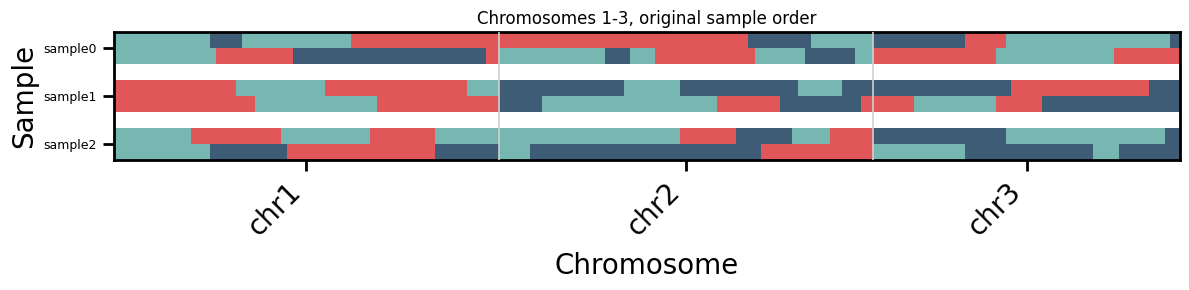

In [13]:
focused_indexes = np.where(np.isin(laiobj.chromosomes.astype(str), ["1", "2", "3"]))[0]
focused = laiobj.filter_windows(indexes=focused_indexes)
focused = focused.filter_samples(samples=selected_samples, reorder=True)

plot_lai(
    focused,
    colors=colors,
    sort=False,
    figsize=(12, 3),
    title="Chromosomes 1-3, original sample order",
    scale=4,
)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()